# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
import os
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

%matplotlib inline


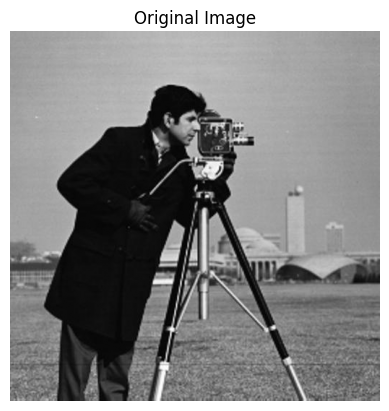

Image mode: L, Image size (W x H): (512, 512)


In [2]:
# ── Load image ────────────────────────────────────
img = Image.open("cameraman.png").convert("L")
img_array = np.array(img)

plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

print(f"Image mode: {img.mode}, Image size (W x H): {img.size}")


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size
print(f"Original size -> width: {width}, height: {height}")

# scaling factors
scale_x = 2
scale_y = 2


Original size -> width: 512, height: 512


In [4]:
# ── 1. Increase size (scale ×2) ────────────────────
new_size = (width * scale_x, height * scale_y)

# Resize the image using PIL's built-in method
scaled_img = img.resize(new_size, Image.Resampling.LANCZOS)


Original size: (512, 512)
Scaled size:   (1024, 1024)


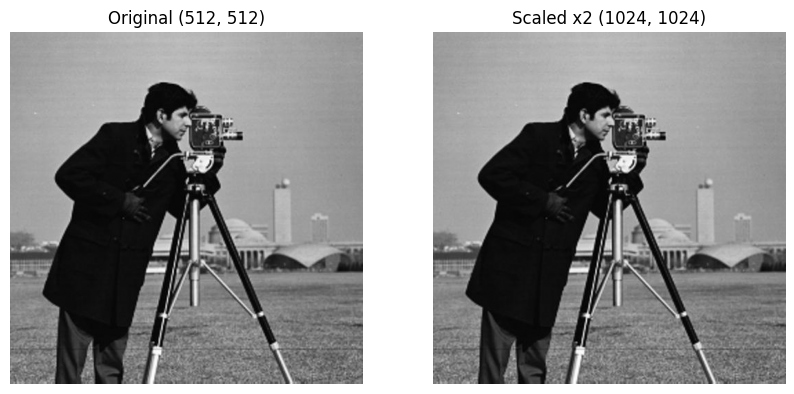

In [5]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print(f"Original size: {img.size}")
print(f"Scaled size:   {scaled_img.size}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title(f'Original {img.size}'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(scaled_img, cmap='gray'), plt.title(f'Scaled x2 {scaled_img.size}'), plt.axis('off')
plt.show()


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
cx, cy = 2, 1
nonuniform_size = (width * cx, height * cy)
print(f"Non-uniform target size (cx={cx}, cy={cy}): {nonuniform_size}")


Non-uniform target size (cx=2, cy=1): (1024, 512)


In [7]:
nonuniform_scaled_img = img.resize(nonuniform_size, Image.Resampling.LANCZOS)


Original size:            (512, 512)
Non-uniform scaled size:  (1024, 512)


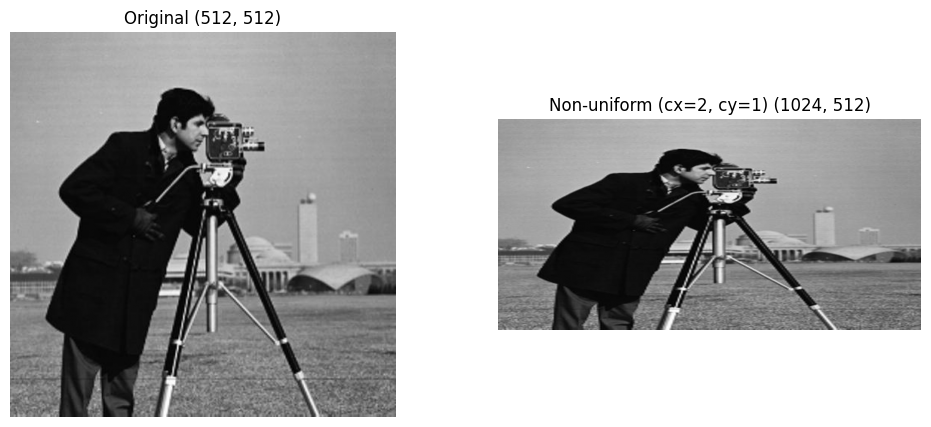

In [8]:
nonuniform_scaled_img.save("task1_1b_nonuniform_scaled.jpg")

print(f"Original size:            {img.size}")
print(f"Non-uniform scaled size:  {nonuniform_scaled_img.size}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title(f'Original {img.size}'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(nonuniform_scaled_img, cmap='gray'), plt.title(f'Non-uniform (cx=2, cy=1) {nonuniform_scaled_img.size}'), plt.axis('off')
plt.show()


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size:  (700, 700)


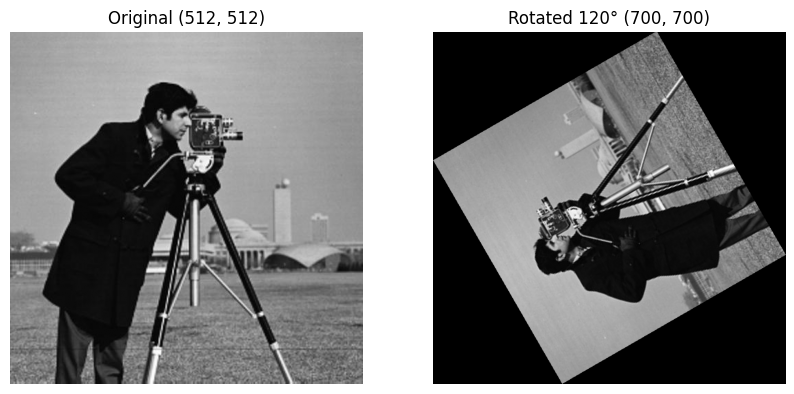

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_img = img.rotate(120, resample=Image.Resampling.BICUBIC, expand=True)

# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img.save("task1_2_rotated.jpg")

print(f"Original size: {img.size}")
print(f"Rotated size:  {rotated_img.size}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title(f'Original {img.size}'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(rotated_img, cmap='gray'), plt.title(f'Rotated 120° {rotated_img.size}'), plt.axis('off')
plt.show()


### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print(f"Image dimensions -> width: {width}, height: {height}")


Image dimensions -> width: 512, height: 512


In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

shx = shear_factor
shy = 0

new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)
print(f"New canvas size: {new_width} x {new_height}")


New canvas size: 768 x 512


In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
shear_matrix = (1, -shx, 0,
                 shy, 1, 0)

sheared_img = img.transform((new_width, new_height), Image.AFFINE, shear_matrix, resample=Image.Resampling.BICUBIC)


Original size: (512, 512)
Sheared size:  (768, 512)


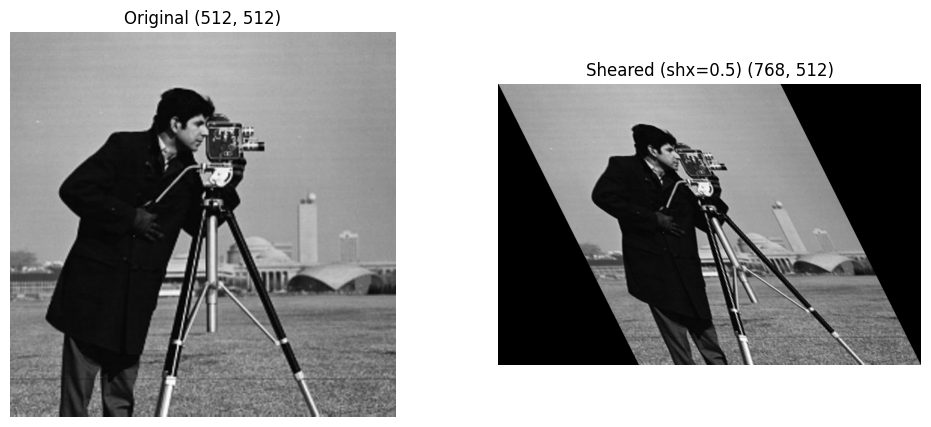

In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")

print(f"Original size: {img.size}")
print(f"Sheared size:  {sheared_img.size}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title(f'Original {img.size}'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(sheared_img, cmap='gray'), plt.title(f'Sheared (shx={shx}) {sheared_img.size}'), plt.axis('off')
plt.show()


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

**Observations:**

- **Shear factor 0.1 → 0.8:** the larger the factor, the more the image slants and the wider the output canvas needs to be (canvas width grows as `width + shear_factor × height`). Small factors (0.1) give a subtle slant; large factors (0.8) produce a strong, elongated parallelogram shape.
- **X-axis vs Y-axis shear:** X-axis shear slides rows sideways (horizontal slant, canvas grows wider); Y-axis shear slides columns up/down (vertical slant, canvas grows taller). Swapping which of `shx`/`shy` is non-zero (and updating the canvas-size formula accordingly) switches between the two.
- **Combined X+Y shear:** setting both `shx` and `shy` to non-zero values shears the image along both axes simultaneously, producing a rhombus-like distortion and requiring the canvas to grow in both width and height.


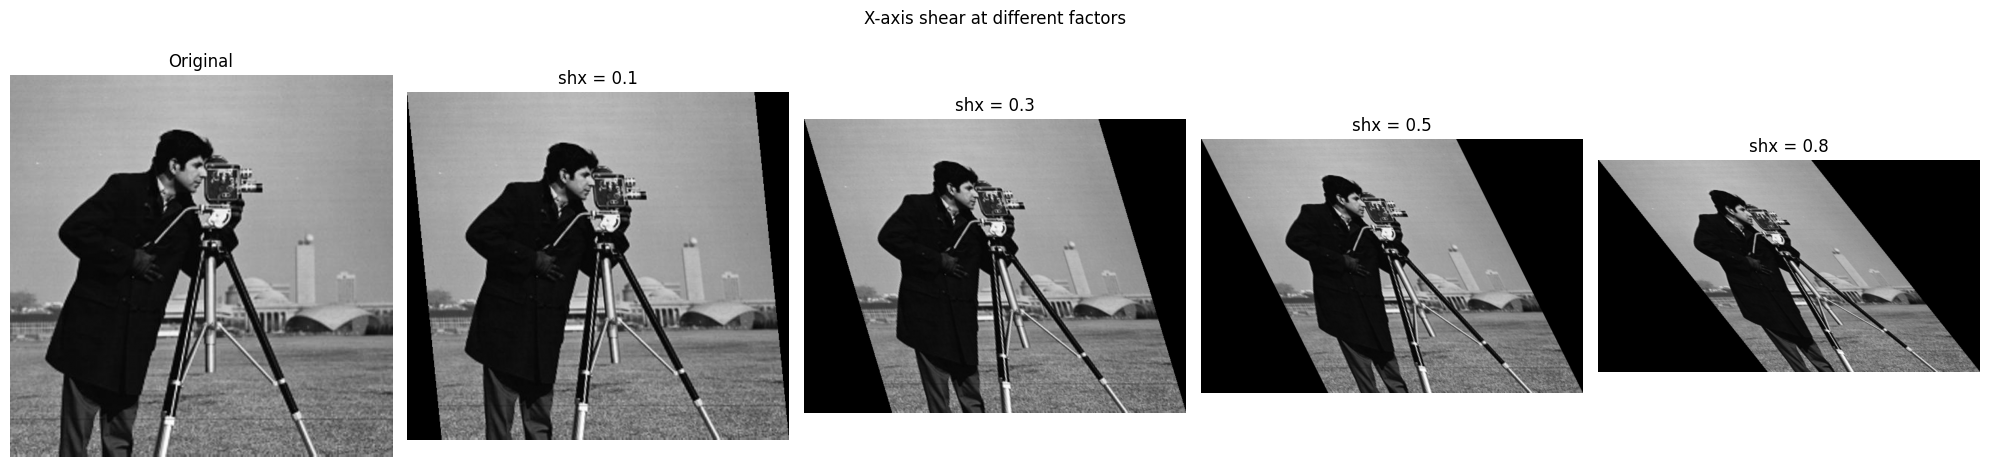

In [14]:
shear_factors = [0.1, 0.3, 0.5, 0.8]

fig, axes = plt.subplots(1, len(shear_factors) + 1, figsize=(20, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for ax, sf in zip(axes[1:], shear_factors):
    shx, shy = sf, 0
    w = int(width + abs(shx) * height)
    h = int(height + abs(shy) * width)
    matrix = (1, -shx, 0, shy, 1, 0)
    sheared = img.transform((w, h), Image.AFFINE, matrix, resample=Image.Resampling.BICUBIC)
    ax.imshow(sheared, cmap='gray')
    ax.set_title(f'shx = {sf}')
    ax.axis('off')

plt.suptitle('X-axis shear at different factors')
plt.tight_layout()
plt.show()


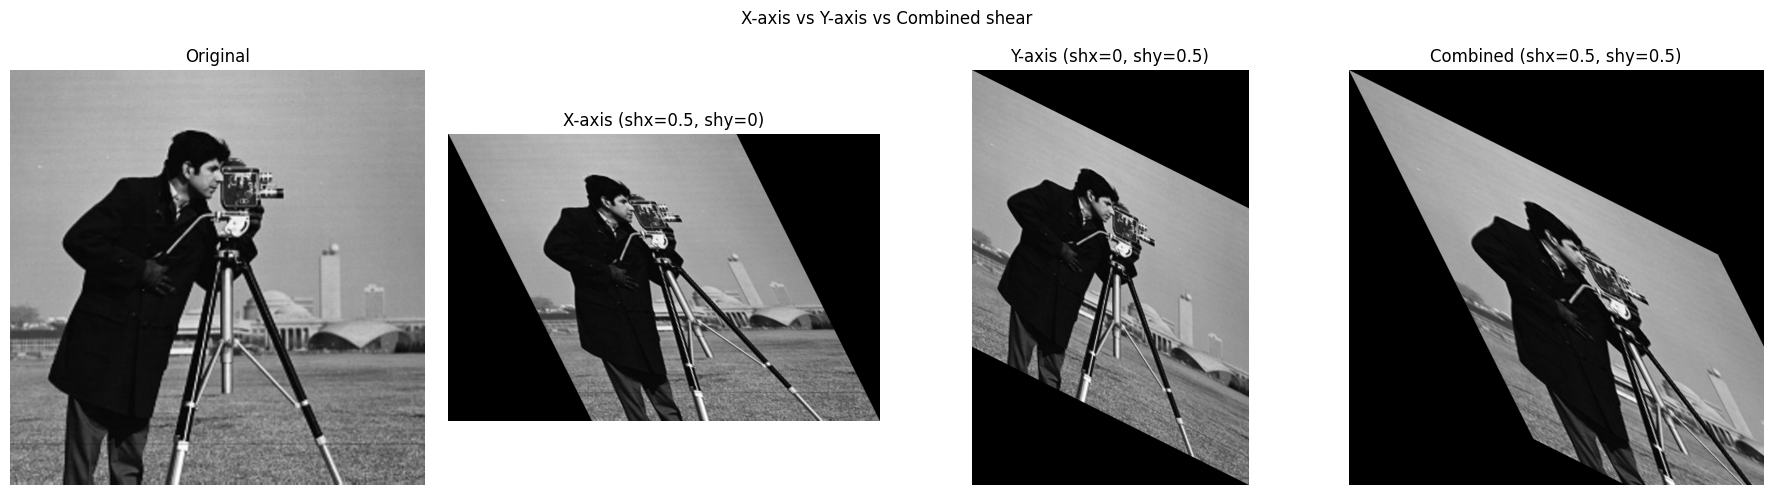

In [15]:
sf = 0.5

variants = {
    "X-axis (shx=0.5, shy=0)":   (sf, 0),
    "Y-axis (shx=0, shy=0.5)":   (0, sf),
    "Combined (shx=0.5, shy=0.5)": (sf, sf),
}

fig, axes = plt.subplots(1, len(variants) + 1, figsize=(18, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for ax, (label, (shx, shy)) in zip(axes[1:], variants.items()):
    w = int(width + abs(shx) * height)
    h = int(height + abs(shy) * width)
    matrix = (1, -shx, 0, -shy, 1, 0)
    sheared = img.transform((w, h), Image.AFFINE, matrix, resample=Image.Resampling.BICUBIC)
    ax.imshow(sheared, cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.suptitle('X-axis vs Y-axis vs Combined shear')
plt.tight_layout()
plt.show()


# Intensity Transformations
Negative · Log · Power Law (Gamma)

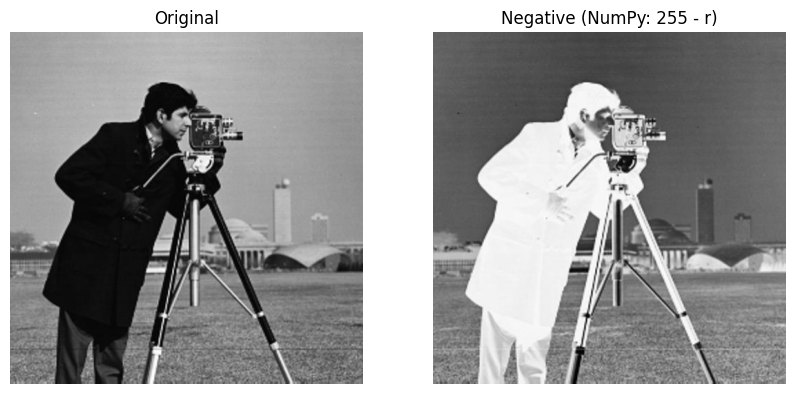

In [16]:
# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
img_array = np.array(img)

negative_array = 255 - img_array
negative_img_np = Image.fromarray(negative_array.astype(np.uint8))

negative_img_np.save("task2_1_negative_numpy.jpg")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(negative_img_np, cmap='gray'), plt.title('Negative (NumPy: 255 - r)'), plt.axis('off')
plt.show()


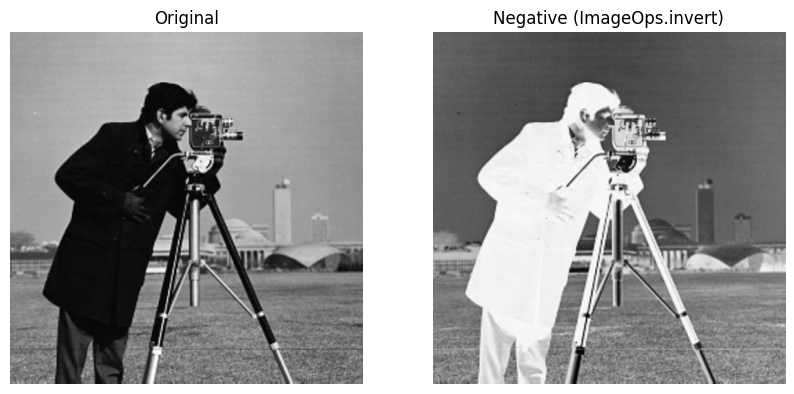

Methods match: True


In [17]:
# Method 2: PIL's ImageOps
negative_img_pil = ImageOps.invert(img.convert('L'))

negative_img_pil.save("task2_1_negative_imageops.jpg")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(negative_img_pil, cmap='gray'), plt.title('Negative (ImageOps.invert)'), plt.axis('off')
plt.show()

print("Methods match:", np.array_equal(np.array(negative_img_np), np.array(negative_img_pil)))


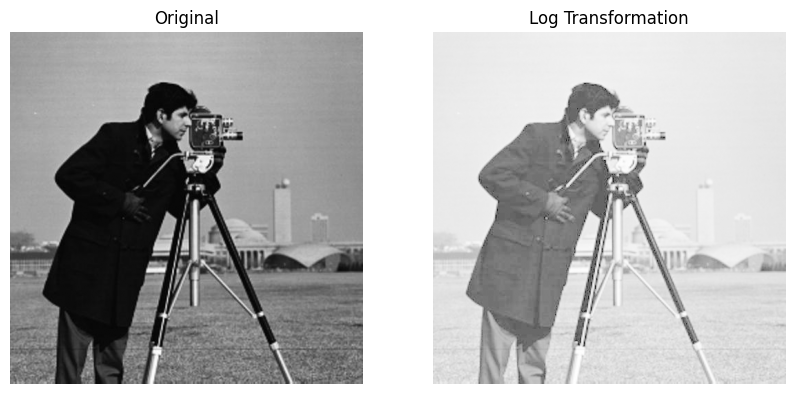

In [18]:
# ── 2. Log transformation ──────────────────────────
img_array = np.array(img).astype(np.float64)

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_array = c * np.log(1 + img_array)
log_array = np.clip(log_array, 0, 255).astype(np.uint8)
log_img = Image.fromarray(log_array)

log_img.save("task2_2_log.jpg")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(log_img, cmap='gray'), plt.title('Log Transformation'), plt.axis('off')
plt.show()


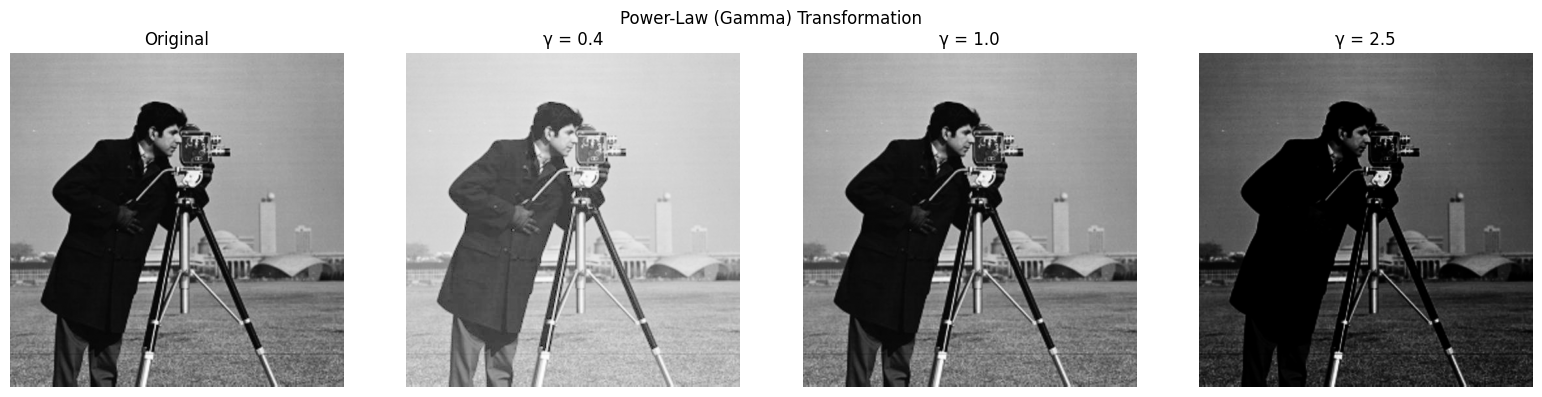

In [19]:
# ── 3. Power-law / Gamma correction ───────────────
img_norm = np.array(img).astype(np.float64) / 255.0
c = 1.0

gammas = [0.4, 1.0, 2.5]

fig, axes = plt.subplots(1, len(gammas) + 1, figsize=(16, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

gamma_imgs = {}
for ax, gamma in zip(axes[1:], gammas):
    gamma_array = c * np.power(img_norm, gamma)
    gamma_array = np.clip(gamma_array * 255, 0, 255).astype(np.uint8)
    gamma_img = Image.fromarray(gamma_array)
    gamma_imgs[gamma] = gamma_img

    ax.imshow(gamma_img, cmap='gray')
    ax.set_title(f'γ = {gamma}')
    ax.axis('off')

    gamma_img.save(f"task2_3_gamma_{gamma}.jpg")

plt.suptitle('Power-Law (Gamma) Transformation')
plt.tight_layout()
plt.show()


In [20]:
saved_files = sorted(f for f in os.listdir('.') if f.startswith('task'))
print("Saved output images:")
for f in saved_files:
    print(" -", f)


Saved output images:
 - task1_1_scaled.jpg
 - task1_1b_nonuniform_scaled.jpg
 - task1_2_rotated.jpg
 - task1_3_sheared.jpg
 - task2_1_negative_imageops.jpg
 - task2_1_negative_numpy.jpg
 - task2_2_log.jpg
 - task2_3_gamma_0.4.jpg
 - task2_3_gamma_1.0.jpg
 - task2_3_gamma_2.5.jpg


**Name:** Fatimah Saad Alghamdi - **ID:** 2240002658

# **THANK YOU!**